In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

from utils import Reservoir, DataGenerator

In [2]:
# ===========================================================
# GLOBAL PLOT STYLE 
# Note: Requires a working LaTeX installation on your system 
# (not in this specific case, the first three lines are commented)
# ===========================================================

plt.rcParams.update({
    # LaTeX and Fonts
    # "text.usetex": True,
    # "font.family": "cmr10",
    # "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.size": 16,         
    "axes.titlesize": 16,      
    "axes.labelsize": 16,      
    "legend.fontsize": 16,    
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,

    # Line widths
    "axes.linewidth": 1.2,     
    "lines.linewidth": 1.5,    
    "lines.markersize": 8,    

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,

    # Grid
    "axes.grid": True,
    "grid.linestyle": "dashed",
    "grid.alpha": 0.2,

    # Legend
    "legend.frameon": False,
    "legend.loc": "best"
    })

## Checkloss function

$$\rho_\tau(r) = \tau \max(r, 0) + (1-\tau)\max(-r, 0)$$

In [3]:
def checkloss(taus, ytrue, ypred):
    loss = 0

    # Loop over each tau
    for i, tau in enumerate(taus):
        # Compute the residuals
        r = ytrue - ypred[:, i].unsqueeze(1)
        
        # Compute the loss for a given tau
        quantile_loss = tau * torch.relu(r) + (1 - tau) * torch.relu(-r)
        loss += torch.mean(quantile_loss)
        
    return loss

## Readout layer

In [4]:
class ReadoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, activation=nn.ReLU):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        # Hidden layers
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(activation())
            prev_dim = h_dim
            
        # Output layer
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

## Generate data/open dataset (FBezzi copy-paste code)

In [5]:
Time_steps = 2000
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()
X.shape, Y.shape

((2000, 1), (2000, 1))

In [6]:
X_train = X[:1000, :]
Y_train = Y[:1000, :]

X_test = X[1000:, :]
Y_test = Y[1000:, :]

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((1000, 1), (1000, 1), (1000, 1), (1000, 1))

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


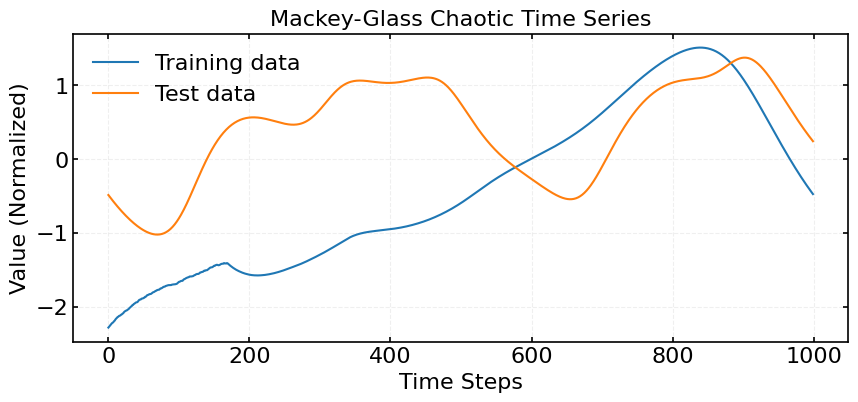

In [7]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train, label="Training data")
plt.plot(X_test, label="Test data")

plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.legend(loc="best", frameon=False)

plt.show()

In [8]:
# Recast data to torch tensors

Xtrain_tensor = torch.from_numpy(S_train).float()
Ytrain_tensor = torch.from_numpy(Y_train).float()

Xtest_tensor = torch.from_numpy(S_test).float()
Ytest_tensor = torch.from_numpy(Y_test).float()

## Train the net

## Grid search on paper suggested parameters

In [9]:
# Hyperparameters to tune
param_grid = { # n.b. for now I tested only the paper suggested parameters, but we can expand them later if needed
    "hidden_dims": [ [512], [512, 256], [512, 256, 128] ], # test 1, 2 or 3 layers
    "activations": [nn.ReLU, nn.Tanh],
    "learning_rates": [0.001, 0.0006]
}

# Define quantiles for median and 95% confidence interval (switch to:
# taus = [0.05, 0.50, 0.95] # if we want to test only the paper suggested quantiles (90% CI) )
taus = [0.025, 0.50, 0.975] 
epochs = 100 

best_mse = float('inf')
best_params = None
best_model = None
best_train_losses = []
best_val_losses = []

print("\nStarting Grid Search...")

# Loop over all combinations of hyperparameters
for hdim in param_grid["hidden_dims"]:
    for act in param_grid["activations"]:
        for lr in param_grid["learning_rates"]:
            
            # Initialize model and optimizer
            model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=hdim, output_dim=len(taus), activation=act)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            
            train_losses = []
            val_losses = []
            
            # Training loop
            for epoch in range(epochs):
                model.train()
                optimizer.zero_grad()
                
                # Forward and Train Loss
                train_preds = model(Xtrain_tensor)
                loss = checkloss(taus, Ytrain_tensor, train_preds) 
                loss.backward()
                optimizer.step()
                
                train_losses.append(loss.item())
                
                # Validation Loss tracking
                model.eval()
                with torch.no_grad():
                    val_preds = model(Xtest_tensor)
                    v_loss = checkloss(taus, Ytest_tensor, val_preds)
                    val_losses.append(v_loss.item())
            
            # Evaluate using MSE of the median as they did in the paper
            model.eval()
            with torch.no_grad():
                final_val_preds = model(Xtest_tensor)
                median_preds = final_val_preds[:, 1].unsqueeze(1)
                mse = torch.mean((Ytest_tensor - median_preds)**2).item()
            
            print(f"Tested Config: Layers={len(hdim)}, Act={act.__name__}, LR={lr} | Val MSE: {mse:.4f}")
            
            # 4. Save the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {"hidden_dims": hdim, "activation": act.__name__, "lr": lr}
                best_model = model
                best_train_losses = train_losses
                best_val_losses = val_losses

print(f"\n==== BEST MODEL ====")
print(f"Parameters: {best_params}")
print(f"Validation MSE: {best_mse:.4f}")


Starting Grid Search...
Tested Config: Layers=1, Act=ReLU, LR=0.001 | Val MSE: 0.0121
Tested Config: Layers=1, Act=ReLU, LR=0.0006 | Val MSE: 0.0024
Tested Config: Layers=1, Act=Tanh, LR=0.001 | Val MSE: 0.0149
Tested Config: Layers=1, Act=Tanh, LR=0.0006 | Val MSE: 0.0224
Tested Config: Layers=2, Act=ReLU, LR=0.001 | Val MSE: 0.0018
Tested Config: Layers=2, Act=ReLU, LR=0.0006 | Val MSE: 0.0010
Tested Config: Layers=2, Act=Tanh, LR=0.001 | Val MSE: 0.0009
Tested Config: Layers=2, Act=Tanh, LR=0.0006 | Val MSE: 0.0006
Tested Config: Layers=3, Act=ReLU, LR=0.001 | Val MSE: 0.0010
Tested Config: Layers=3, Act=ReLU, LR=0.0006 | Val MSE: 0.0034
Tested Config: Layers=3, Act=Tanh, LR=0.001 | Val MSE: 0.0035
Tested Config: Layers=3, Act=Tanh, LR=0.0006 | Val MSE: 0.0024

==== BEST MODEL ====
Parameters: {'hidden_dims': [512, 256], 'activation': 'Tanh', 'lr': 0.0006}
Validation MSE: 0.0006


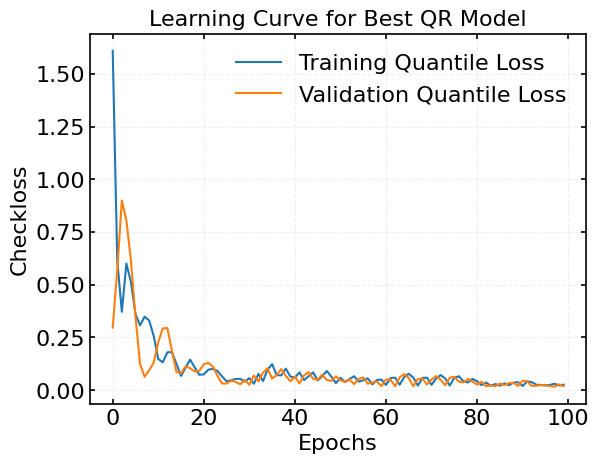

In [10]:
# Learning curve 
plt.figure()
plt.plot(best_train_losses, label="Training Quantile Loss", color="tab:blue")
plt.plot(best_val_losses, label="Validation Quantile Loss", color="tab:orange")

plt.xlabel("Epochs")
plt.ylabel("Checkloss")
plt.title(f"Learning Curve for Best QR Model")
plt.legend(frameon=False, loc="best")
plt.grid(True, linestyle="dashed", alpha=0.2)
plt.show()

## Training on the best model

In [ ]:
# Final Training on the best model
best_activation = getattr(nn, best_params["activation"]) 

# Initialize the best model
best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])

# Train for many epochs
epochs = 500  
train_losses = []
val_losses = []
train_mses = []
val_mses = []

print(f"Train the best model for {epochs} epochs with best params: {best_params}...")
# Training loop
for epoch in range(epochs):
    best_model.train()
    optimizer.zero_grad()
    
    # Forward and loss on training
    train_preds = best_model(Xtrain_tensor)
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Compute metrics on Validation set
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        v_loss = checkloss(taus, Ytest_tensor, val_preds)
        val_losses.append(v_loss.item())
        
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

Train the best model for 500 epochs with best params: {'hidden_dims': [512, 256], 'activation': 'Tanh', 'lr': 0.0006}...
Training completed! Final MSE on Validation set: 0.0036


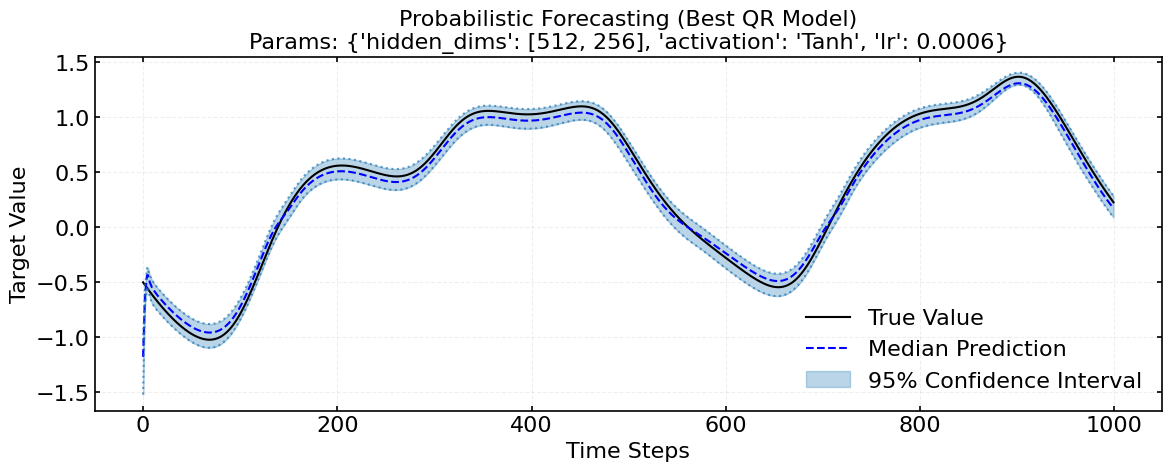

Empirical coverage: 99.50% (Target: 95.00%)


In [12]:
best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)

# Extract quantiles
y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()

y_true = Ytest_tensor.numpy()

# Plot results
plt.figure(figsize=(12, 5))

# Plot true value
plt.plot(y_true, label="True Value", color="black", linewidth=1.5)

# Plot median
plt.plot(y_pred_50, label="Median Prediction", color="blue", linestyle="--", linewidth=1.5)

# Plot CI
plt.plot(y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)
plt.fill_between(range(y_true.shape[0]), 
                 y_pred_025.flatten(), 
                 y_pred_975.flatten(), 
                 color="tab:blue", alpha=0.3, label="95% Confidence Interval")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)

plt.tight_layout()
plt.show()

# Compute coverage
into_interval = (y_true.flatten() >= y_pred_025.flatten()) & (y_true.flatten() <= y_pred_975.flatten())
coverage = into_interval.mean()*100
print(f"Empirical coverage: {coverage:.2f}% (Target: 95.00%)")

## Do the same with real data

In [13]:
# Load matrices data
TRAIN_FILENAME = "100307.REST1.LR.SchaeferS.ptseries.mat"
TEST_FILENAME = "100307.REST2.LR.SchaeferS.ptseries.mat"

train_mat = sio.loadmat(TRAIN_FILENAME)
test_mat = sio.loadmat(TEST_FILENAME)

train_data = [v for k, v in train_mat.items() if not k.startswith('__')][0]
test_data = [v for k, v in test_mat.items() if not k.startswith('__')][0]

# Scale data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

target_region = 0 

X_train = train_scaled[:-1, :]
Y_train = train_scaled[1:, target_region].reshape(-1, 1)

X_test = test_scaled[:-1, :]
Y_test = test_scaled[1:, target_region].reshape(-1, 1)

In [14]:
res = Reservoir(input_dim=X_train.shape[1], 
                reservoir_dim=500, 
                spectral_radius=0.9, 
                seed=42)

S_train = res.get_states(X_train)
S_test  = res.get_states(X_test)

In [15]:
# Recast data to torch tensors

Xtrain_tensor = torch.from_numpy(S_train).float()
Ytrain_tensor = torch.from_numpy(Y_train).float()

Xtest_tensor = torch.from_numpy(S_test).float()
Ytest_tensor = torch.from_numpy(Y_test).float()

## Train the net

## Grid search on paper suggested parameters

In [16]:
# Hyperparameters to tune
param_grid = { # n.b. for now I tested only the paper suggested parameters, but we can expand them later if needed
    "hidden_dims": [ [512], [512, 256], [512, 256, 128] ], # test 1, 2 or 3 layers
    "activations": [nn.ReLU, nn.Tanh],
    "learning_rates": [0.001, 0.0006]
}

# Define quantiles for median and 95% confidence interval (switch to:
# taus = [0.05, 0.50, 0.95] # if we want to test only the paper suggested quantiles (90% CI) )
taus = [0.025, 0.50, 0.975] 
epochs = 100 

best_mse = float('inf')
best_params = None
best_model = None
best_train_losses = []
best_val_losses = []

print("\nStarting Grid Search...")

# Loop over all combinations of hyperparameters
for hdim in param_grid["hidden_dims"]:
    for act in param_grid["activations"]:
        for lr in param_grid["learning_rates"]:
            
            # Initialize model and optimizer
            model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=hdim, output_dim=len(taus), activation=act)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            
            train_losses = []
            val_losses = []
            
            # Training loop
            for epoch in range(epochs):
                model.train()
                optimizer.zero_grad()
                
                # Forward and Train Loss
                train_preds = model(Xtrain_tensor)
                loss = checkloss(taus, Ytrain_tensor, train_preds) 
                loss.backward()
                optimizer.step()
                
                train_losses.append(loss.item())
                
                # Validation Loss tracking
                model.eval()
                with torch.no_grad():
                    val_preds = model(Xtest_tensor)
                    v_loss = checkloss(taus, Ytest_tensor, val_preds)
                    val_losses.append(v_loss.item())
            
            # Evaluate using MSE of the median as they did in the paper
            model.eval()
            with torch.no_grad():
                final_val_preds = model(Xtest_tensor)
                median_preds = final_val_preds[:, 1].unsqueeze(1)
                mse = torch.mean((Ytest_tensor - median_preds)**2).item()
            
            print(f"Tested Config: Layers={len(hdim)}, Act={act.__name__}, LR={lr} | Val MSE: {mse:.4f}")
            
            # 4. Save the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {"hidden_dims": hdim, "activation": act.__name__, "lr": lr}
                best_model = model
                best_train_losses = train_losses
                best_val_losses = val_losses

print(f"\n==== BEST MODEL ====")
print(f"Parameters: {best_params}")
print(f"Validation MSE: {best_mse:.4f}")


Starting Grid Search...
Tested Config: Layers=1, Act=ReLU, LR=0.001 | Val MSE: 1.0552
Tested Config: Layers=1, Act=ReLU, LR=0.0006 | Val MSE: 0.9990
Tested Config: Layers=1, Act=Tanh, LR=0.001 | Val MSE: 1.1871
Tested Config: Layers=1, Act=Tanh, LR=0.0006 | Val MSE: 1.0290
Tested Config: Layers=2, Act=ReLU, LR=0.001 | Val MSE: 1.1163
Tested Config: Layers=2, Act=ReLU, LR=0.0006 | Val MSE: 0.9786
Tested Config: Layers=2, Act=Tanh, LR=0.001 | Val MSE: 1.0775
Tested Config: Layers=2, Act=Tanh, LR=0.0006 | Val MSE: 1.0611
Tested Config: Layers=3, Act=ReLU, LR=0.001 | Val MSE: 1.0246
Tested Config: Layers=3, Act=ReLU, LR=0.0006 | Val MSE: 0.9527
Tested Config: Layers=3, Act=Tanh, LR=0.001 | Val MSE: 0.9246
Tested Config: Layers=3, Act=Tanh, LR=0.0006 | Val MSE: 1.2959

==== BEST MODEL ====
Parameters: {'hidden_dims': [512, 256, 128], 'activation': 'Tanh', 'lr': 0.001}
Validation MSE: 0.9246


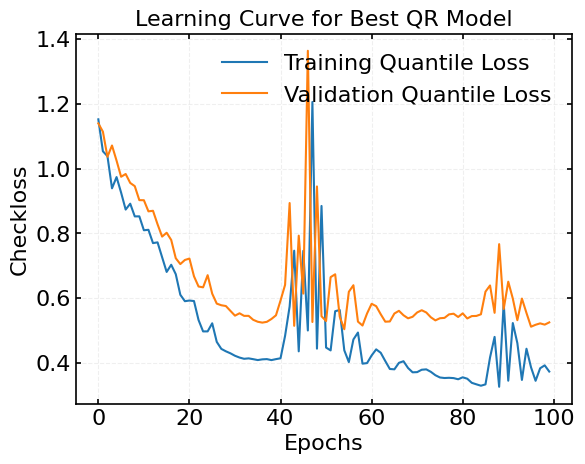

In [17]:
# Learning curve 
plt.figure()
plt.plot(best_train_losses, label="Training Quantile Loss", color="tab:blue")
plt.plot(best_val_losses, label="Validation Quantile Loss", color="tab:orange")

plt.xlabel("Epochs")
plt.ylabel("Checkloss")
plt.title(f"Learning Curve for Best QR Model")
plt.legend(frameon=False, loc="best")
plt.grid(True, linestyle="dashed", alpha=0.2)
plt.show()

## Training on the best model

In [18]:
# Final Training on the best model
best_activation = getattr(nn, best_params["activation"]) 

# Initialize the best model
best_model = ReadoutMLP(input_dim=Xtrain_tensor.shape[1], hidden_dims=best_params["hidden_dims"], output_dim=len(taus), activation=best_activation)
optimizer = torch.optim.Adam(best_model.parameters(), lr=best_params["lr"])

# Train for many epochs
epochs = 500  
train_losses = []
val_losses = []
train_mses = []
val_mses = []

print(f"Train the best model for {epochs} epochs with best params: {best_params}...")
# Training loop
for epoch in range(epochs):
    best_model.train()
    optimizer.zero_grad()
    
    # Forward and loss on training
    train_preds = best_model(Xtrain_tensor)
    loss = checkloss(taus, Ytrain_tensor, train_preds)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    # Compute metrics on Validation set
    best_model.eval()
    with torch.no_grad():
        val_preds = best_model(Xtest_tensor)
        v_loss = checkloss(taus, Ytest_tensor, val_preds)
        val_losses.append(v_loss.item())
        
        val_median = val_preds[:, 1].unsqueeze(1)
        v_mse = torch.mean((Ytest_tensor - val_median)**2).item()
        val_mses.append(v_mse)

print(f"Training completed! Final MSE on Validation set: {val_mses[-1]:.4f}")

Train the best model for 500 epochs with best params: {'hidden_dims': [512, 256, 128], 'activation': 'Tanh', 'lr': 0.001}...
Training completed! Final MSE on Validation set: 1.4514


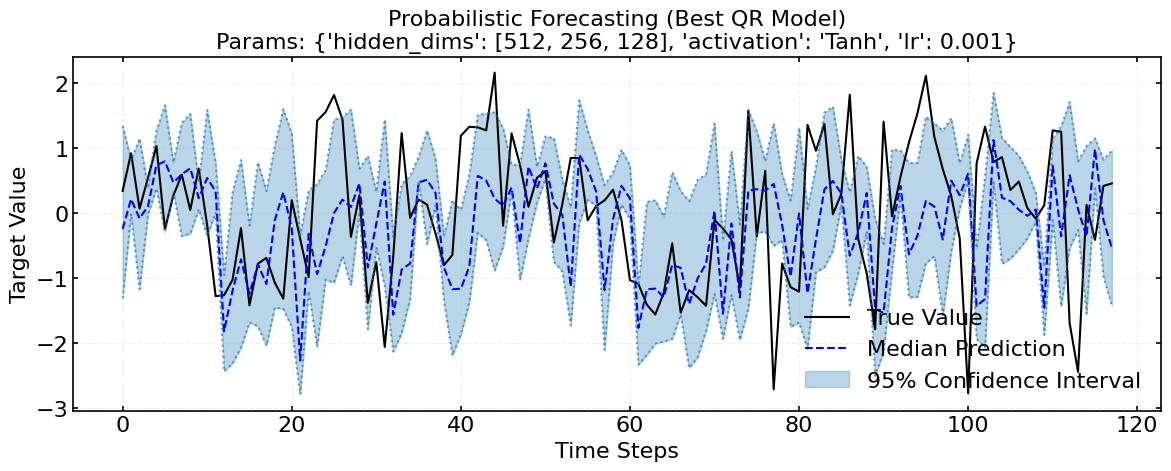

Empirical coverage: 62.71% (Target: 95.00%)


In [19]:
best_model.eval()
with torch.no_grad():
    test_predictions = best_model(Xtest_tensor)

# Extract quantiles
y_pred_025 = test_predictions[:, 0].numpy()
y_pred_50  = test_predictions[:, 1].numpy()
y_pred_975 = test_predictions[:, 2].numpy()

y_true = Ytest_tensor.numpy()

# Plot results
plt.figure(figsize=(12, 5))

# Plot true value
plt.plot(y_true, label="True Value", color="black", linewidth=1.5)

# Plot median
plt.plot(y_pred_50, label="Median Prediction", color="blue", linestyle="--", linewidth=1.5)

# Plot CI
plt.plot(y_pred_975, color="tab:blue", linestyle=":", alpha=0.7)
plt.plot(y_pred_025, color="tab:blue", linestyle=":", alpha=0.7)
plt.fill_between(range(y_true.shape[0]), 
                 y_pred_025.flatten(), 
                 y_pred_975.flatten(), 
                 color="tab:blue", alpha=0.3, label="95% Confidence Interval")

plt.xlabel("Time Steps")
plt.ylabel("Target Value")
plt.title(f"Probabilistic Forecasting (Best QR Model)\nParams: {best_params}")
plt.legend(loc="best", frameon=False)

plt.tight_layout()
plt.show()

# Compute coverage
into_interval = (y_true.flatten() >= y_pred_025.flatten()) & (y_true.flatten() <= y_pred_975.flatten())
coverage = into_interval.mean()*100
print(f"Empirical coverage: {coverage:.2f}% (Target: 95.00%)")